# MNIST CNN với TensorFlow / Keras

Cấu trúc giống các notebook trước.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct, time, os
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TF version:', tf.__version__)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 80

DATA_DIR = Path('../data')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)
print('Data dir:', DATA_DIR.resolve())
print('Model dir:', MODEL_DIR.resolve())

TF version: 2.21.0
Data dir: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\data
Model dir: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models


## 1. Load dữ liệu MNIST từ file idx

In [2]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return data

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_full = load_mnist_images(DATA_DIR / 'train-images.idx3-ubyte')
y_train_full = load_mnist_labels(DATA_DIR / 'train-labels.idx1-ubyte')
X_test = load_mnist_images(DATA_DIR / 't10k-images.idx3-ubyte')
y_test = load_mnist_labels(DATA_DIR / 't10k-labels.idx1-ubyte')
print('Train:', X_train_full.shape, y_train_full.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [3]:
N_VAL = 5000
idx = np.random.permutation(len(X_train_full))
X_val = X_train_full[idx[:N_VAL]]; y_val = y_train_full[idx[:N_VAL]]
X_train = X_train_full[idx[N_VAL:]]; y_train = y_train_full[idx[N_VAL:]]

X_train = (X_train.astype(np.float32)/255.0)[..., None]
X_val   = (X_val.astype(np.float32)/255.0)[..., None]
X_test_t= (X_test.astype(np.float32)/255.0)[..., None]
print(X_train.shape, X_val.shape, X_test_t.shape)

(55000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)


## 2. EDA

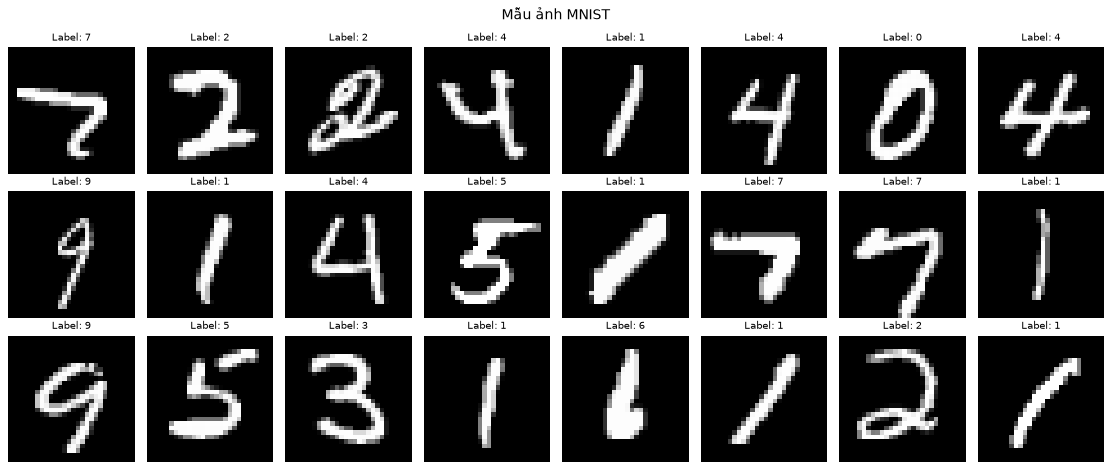

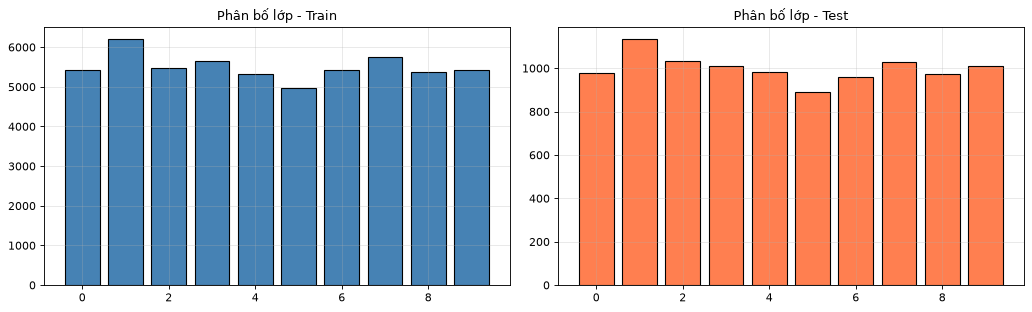

In [4]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, :, :, 0], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Mẫu ảnh MNIST', fontsize=13)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
u, c = np.unique(y_train, return_counts=True)
axes[0].bar(u, c, color='steelblue', edgecolor='k')
axes[0].set_title('Phân bố lớp - Train'); axes[0].grid(alpha=0.3)
u2, c2 = np.unique(y_test, return_counts=True)
axes[1].bar(u2, c2, color='coral', edgecolor='k')
axes[1].set_title('Phân bố lớp - Test'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Xây dựng mô hình CNN

In [5]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         200,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 206,922 (808.29 KB)

 Trainable params: 206,922 (808.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [6]:
best_path = MODEL_DIR / 'mnist_cnn_tensorflow.keras'
cb = [
    callbacks.ModelCheckpoint(str(best_path), save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max')
]
start = time.time()
hist = model.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=6, batch_size=128,
                 callbacks=cb, verbose=1)
print(f'Total time: {time.time()-start:.1f}s')

Epoch 1/6
429/430 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9133 - loss: 0.2908
Epoch 1: val_accuracy improved from None to 0.97600, saving model to ..\models\mnist_cnn_tensorflow.keras

Epoch 1: finished saving model to ..\models\mnist_cnn_tensorflow.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9135 - loss: 0.2904 - val_accuracy: 0.9760 - val_loss: 0.0797
Epoch 2/6
426/430 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9734 - loss: 0.0865
Epoch 2: val_accuracy improved from 0.97600 to 0.98320, saving model to ..\models\mnist_cnn_tensorflow.keras

Epoch 2: finished saving model to ..\models\mnist_cnn_tensorflow.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9735 - loss: 0.0864 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 3/6
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9810 - loss: 0.0612
Epoch 3: val_accuracy improved from 0.98320 to 0.98800, saving model to ..\models\mnist_cnn_tensorflow.keras

Epoch 3: finished saving model to ..

## 5. Learning Curves

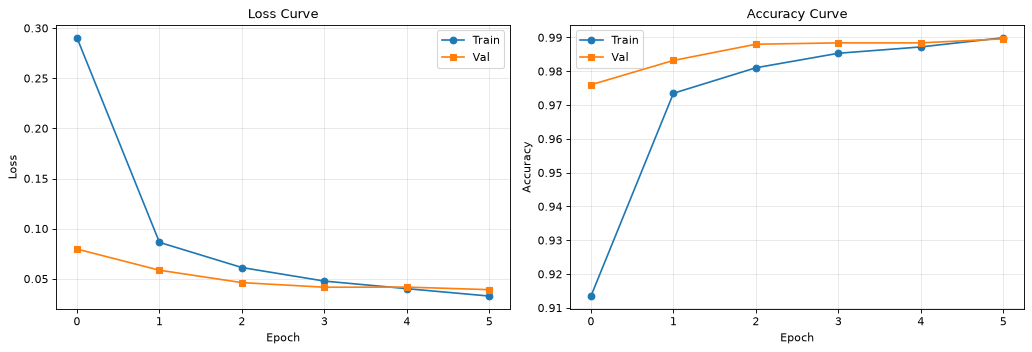

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist.history['loss'], 'o-', label='Train')
axes[0].plot(hist.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(hist.history['accuracy'], 'o-', label='Train')
axes[1].plot(hist.history['val_accuracy'], 's-', label='Val')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Đánh giá Test set

In [8]:
model = tf.keras.models.load_model(str(best_path))
test_loss, test_acc = model.evaluate(X_test_t, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

probs = model.predict(X_test_t, verbose=0)
y_pred = probs.argmax(1)

Test Loss: 0.0278, Test Accuracy: 0.9912


## 7. Confusion Matrix

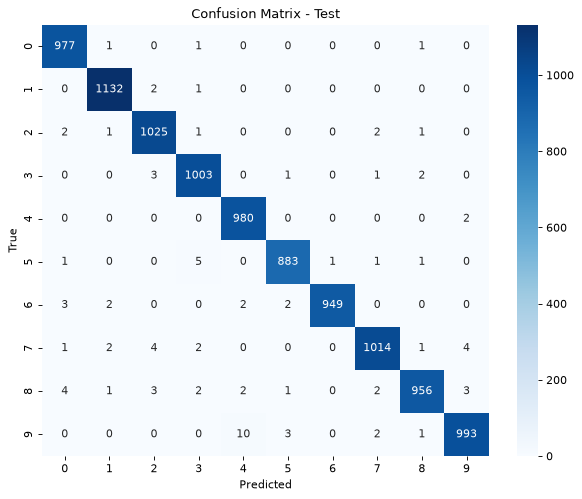

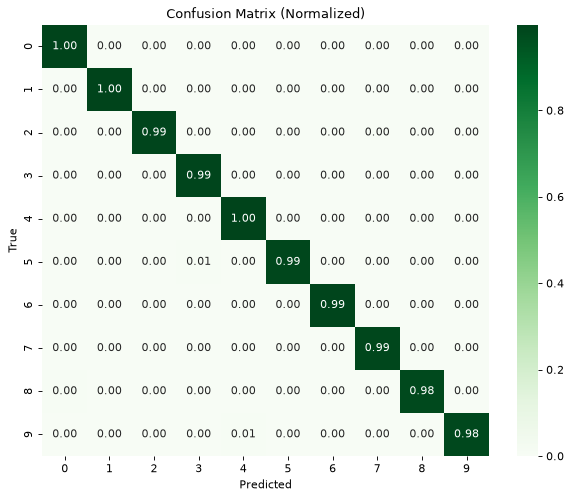

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

## 8. Classification Report

In [10]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9889    0.9969    0.9929       980
           1     0.9939    0.9974    0.9956      1135
           2     0.9884    0.9932    0.9908      1032
           3     0.9882    0.9931    0.9906      1010
           4     0.9859    0.9980    0.9919       982
           5     0.9921    0.9899    0.9910       892
           6     0.9989    0.9906    0.9948       958
           7     0.9922    0.9864    0.9893      1028
           8     0.9927    0.9815    0.9871       974
           9     0.9910    0.9841    0.9876      1009

    accuracy                         0.9912     10000
   macro avg     0.9912    0.9911    0.9912     10000
weighted avg     0.9912    0.9912    0.9912     10000



## 9. Xem dự đoán sai

Số mẫu sai: 88/10000


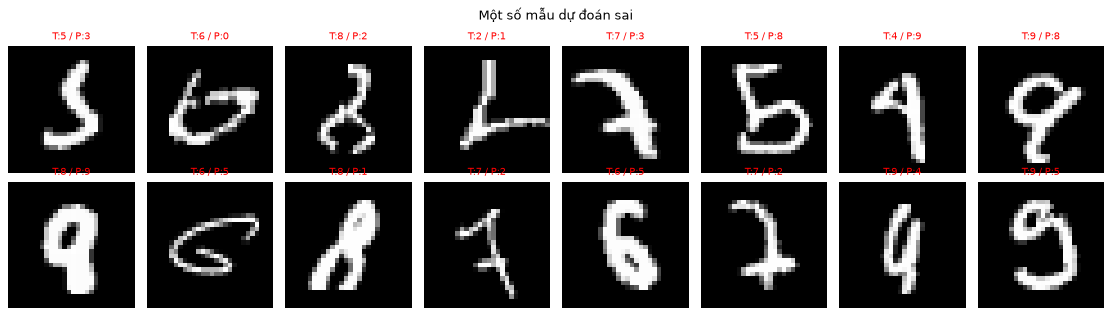

In [11]:
wrong = np.where(y_pred != y_test)[0]
print(f'Số mẫu sai: {len(wrong)}/{len(y_test)}')
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    k = wrong[i]
    ax.imshow(X_test_t[k, :, :, 0], cmap='gray')
    ax.set_title(f'T:{y_test[k]} / P:{y_pred[k]}', fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Một số mẫu dự đoán sai', fontsize=12)
plt.tight_layout(); plt.show()

In [12]:
print('Best model saved at:', best_path.resolve())

Best model saved at: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models\mnist_cnn_tensorflow.keras
